# BAB 4 — Skenario 2: Pelatihan Arsitektur Penuh (AttentiveSkel-3D)

Notebook ini melatih **model final yang diusulkan** dalam skripsi: AttentiveSkel-3D dengan seluruh modul atensi biomekanikal aktif penuh. Ini adalah *upper-bound* dari keseluruhan eksperimen dan merupakan kontribusi utama penelitian.

## Arsitektur yang Digunakan

```
AttentiveSkel3D(use_spatial_prior=True, use_learned_spatial=True, use_temporal_attention=True)
```

| Modul | Status | Fungsi |
|---|---|---|
| **Biomechanical Spatial Prior (BSP)** | ✅ AKTIF | Bobot per-sendi learnable sebelum conv blocks — inductive bias biomekanikal |
| **Learned Spatial Attention** | ✅ AKTIF | Channel Attention (SE-style) setelah `conv_block_3` — pilih channel paling informatif |
| **Temporal Attention** | ✅ AKTIF | Softmax frame-weighting — fokus pada frame-frame kritis dalam sekuens gerak |

## Peran dalam Narasi Skripsi

| Skenario | Model | Tujuan |
|---|---|---|
| Skenario 1 *(sudah dijalankan)* | Baseline — 3D-CNN Murni | Lower-bound, tanpa atensi apapun |
| **Skenario 2 ← notebook ini** | **AttentiveSkel-3D Penuh** | **Model yang diusulkan — upper-bound** |
| Skenario 3 *(sudah dijalankan)* | Ablasi A / B / C | Dekomposisi kontribusi tiap modul |

> **Hipotesis:** Model penuh (Skenario 2) akan melampaui Baseline (Skenario 1) dan semua varian ablasi, membuktikan bahwa fusi ketiga modul atensi secara sinergis berkontribusi pada akurasi klasifikasi gerakan latihan beban.

| Parameter | Nilai |
|---|---|
| Model | `AttentiveSkel3D()` — semua modul aktif |
| Optimizer | Adam (`lr=1e-3`) |
| Loss | CrossEntropyLoss |
| Epochs | 100 |
| Batch size | 16 |
| Split | 70% train / 15% val / 15% test |
| Output model | `AttentiveSkel3D_Final.pth` |

In [1]:
# ============================================================
# Cell 2: Import library, konfigurasi device, dan muat dataset
# ============================================================
import sys
from pathlib import Path

# Tambahkan root proyek ke sys.path agar modul src/ dapat diimport
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Modul proyek
from src.data.dataset import create_dataloaders
from src.models.model_3dcnn import AttentiveSkel3D, count_parameters
from src.models.train import train_model

# Konfigurasi device: gunakan GPU jika tersedia, fallback ke CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[INFO] PyTorch  : {torch.__version__}")
print(f"[INFO] Device   : {device}")
if device.type == "cuda":
    print(f"[INFO] GPU      : {torch.cuda.get_device_name(0)}")

# ── Muat Dataset ──────────────────────────────────────────
MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_manifest.csv"
SAVE_DIR      = PROJECT_ROOT / "models" / "saved_models"

train_loader, val_loader, test_loader = create_dataloaders(
    csv_file    = MANIFEST_PATH,
    batch_size  = 16,
    train_ratio = 0.70,
    val_ratio   = 0.15,
    num_workers = 0,       # 0 di Windows untuk menghindari masalah multiprocessing
    random_seed = 42,
)

n_train = len(train_loader.dataset)
n_val   = len(val_loader.dataset)
n_test  = len(test_loader.dataset)
n_total = n_train + n_val + n_test

print(f"\n[INFO] Total sampel       : {n_total}")
print(f"[INFO] Train / Val / Test : {n_train} / {n_val} / {n_test}")
print(f"[INFO] Iterasi per epoch  : {len(train_loader)}")

# ── Loss Function & Optimizer ─────────────────────────────
# (Optimizer akan di-bind ke model di Cell 3 setelah model diinisialisasi)
print(f"\n[INFO] Criterion          : CrossEntropyLoss")
print(f"[INFO] Optimizer          : Adam (lr=1e-3)")
print(f"[INFO] Save dir           : {SAVE_DIR}")

[INFO] PyTorch  : 2.5.1
[INFO] Device   : cuda
[INFO] GPU      : NVIDIA GeForce RTX 3060 Ti
Dataset split selesai (seed=42):
  Train  :  340 sampel → 21 batch
  Val    :   73 sampel → 5 batch
  Test   :   74 sampel → 5 batch

[INFO] Total sampel       : 487
[INFO] Train / Val / Test : 340 / 73 / 74
[INFO] Iterasi per epoch  : 21

[INFO] Criterion          : CrossEntropyLoss
[INFO] Optimizer          : Adam (lr=1e-3)
[INFO] Save dir           : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models


In [2]:
# ============================================================
# Cell 3: Inisialisasi Model Penuh, Loss Function, dan Optimizer
# ============================================================

# Inisialisasi AttentiveSkel3D tanpa argumen tambahan:
# Semua parameter default = True → model berjalan dalam bentuk paling sempurna.
#   use_spatial_prior     = True  → BSP aktif
#   use_learned_spatial   = True  → Channel Attention aktif
#   use_temporal_attention= True  → Temporal Attention aktif
model_full = AttentiveSkel3D().to(device)

total_params = count_parameters(model_full)

print(f"[INFO] Model              : AttentiveSkel-3D (Arsitektur Penuh)")
print(f"[INFO] use_spatial_prior      : {model_full.use_spatial_prior}")
print(f"[INFO] use_learned_spatial    : {model_full.use_learned_spatial}")
print(f"[INFO] use_temporal_attention : {model_full.use_temporal_attention}")
print(f"[INFO] Parameter trainable    : {total_params:,}")

# Loss function: CrossEntropyLoss mencakup Softmax secara internal
criterion = nn.CrossEntropyLoss()

# Adam lr=1e-3 — konsisten dengan Skenario 1 (Baseline) agar perbandingan adil
optimizer = torch.optim.Adam(model_full.parameters(), lr=1e-3)

print(f"\n[INFO] Loss function      : CrossEntropyLoss")
print(f"[INFO] Optimizer          : Adam (lr=1e-3)")

[INFO] Model              : AttentiveSkel-3D (Arsitektur Penuh)
[INFO] use_spatial_prior      : True
[INFO] use_learned_spatial    : True
[INFO] use_temporal_attention : True
[INFO] Parameter trainable    : 110,372

[INFO] Loss function      : CrossEntropyLoss
[INFO] Optimizer          : Adam (lr=1e-3)


In [3]:
# ============================================================
# Cell 4: Training Loop — Latih Model Penuh AttentiveSkel-3D
# ============================================================
SAVE_FILENAME = "AttentiveSkel3D_Final.pth"

print(f"[INFO] Model terbaik akan disimpan ke: {SAVE_DIR / SAVE_FILENAME}\n")

# train_model akan:
#   1. Melatih selama num_epochs epoch
#   2. Evaluasi validasi di setiap akhir epoch
#   3. Simpan bobot terbaik (val_loss terkecil) ke disk secara otomatis
#   4. Return dict history berisi semua metric per epoch
history = train_model(
    model         = model_full,
    train_loader  = train_loader,
    val_loader    = val_loader,
    criterion     = criterion,
    optimizer     = optimizer,
    num_epochs    = 100,
    device        = device,
    save_dir      = SAVE_DIR,
    save_filename = SAVE_FILENAME,
    verbose       = True,
)

print(f"\n{'='*55}")
print(f"  TRAINING SELESAI — AttentiveSkel-3D PENUH")
print(f"{'='*55}")
print(f"  Epoch terbaik               : {history['best_epoch']}")
print(f"  Val Loss terbaik            : {history['best_val_loss']:.4f}")
print(f"  Val Accuracy @ best epoch   : {history['val_acc'][history['best_epoch']-1]*100:.2f}%")
print(f"  Train Accuracy (epoch akhir): {history['train_acc'][-1]*100:.2f}%")
print(f"  Val Accuracy  (epoch akhir) : {history['val_acc'][-1]*100:.2f}%")
print(f"{'='*55}")
print(f"  Model disimpan di: {SAVE_DIR / SAVE_FILENAME}")

[INFO] Model terbaik akan disimpan ke: D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models\AttentiveSkel3D_Final.pth

  Memulai pelatihan AttentiveSkel-3D
  Device    : cuda
  Epochs    : 100
  Save path : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models\AttentiveSkel3D_Final.pth
Epoch [  1/100] ✓ | Train Loss: 0.6851 | Train Acc:  61.90% | Val Loss: 0.6702 | Val Acc:  54.79% | Waktu: 0.5s
Epoch [  2/100] ✓ | Train Loss: 0.6432 | Train Acc:  69.05% | Val Loss: 0.5945 | Val Acc:  64.38% | Waktu: 0.2s
Epoch [  3/100] ✓ | Train Loss: 0.5368 | Train Acc:  80.36% | Val Loss: 0.5366 | Val Acc:  84.93% | Waktu: 0.2s
Epoch [  4/100] ✓ | Train Loss: 0.4414 | Train Acc:  84.82% | Val Loss: 0.3934 | Val Acc:  89.04% | Waktu: 0.2s
Epoch [  5/100]   | Train Loss: 0.3603 | Train Acc:  88.69% | Val Loss: 0.4077 | Val Acc:  83.56% | Waktu: 0.3s
Epoch [  6/100] ✓ | Train Loss: 0.3026 | Train Acc:  91.67% | Val Loss: 0.3209 | Val Acc

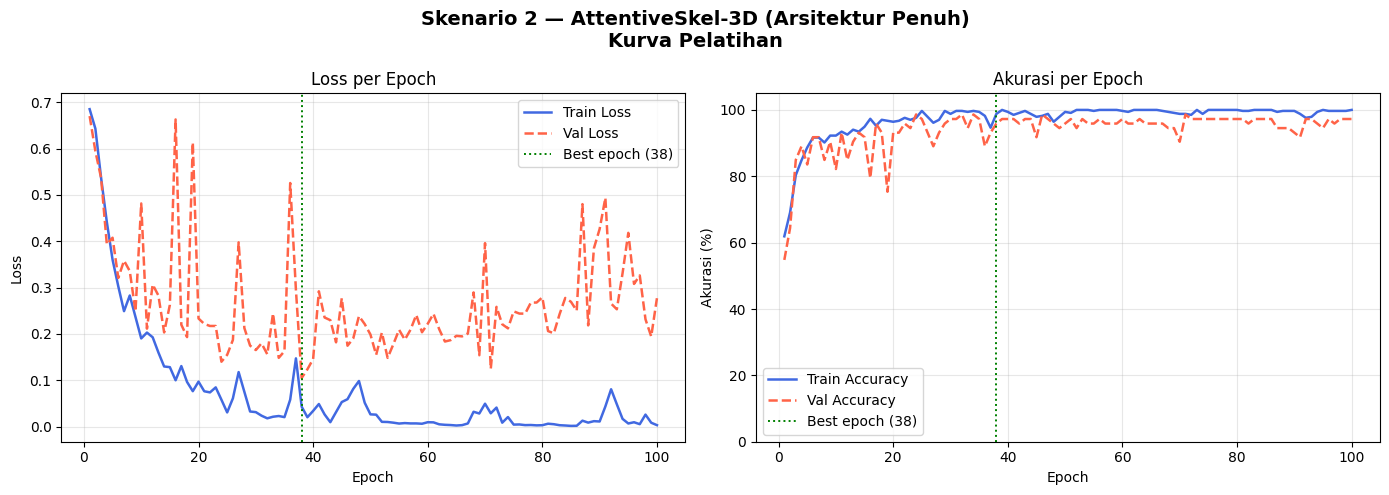


  RINGKASAN HASIL — AttentiveSkel-3D PENUH SKENARIO 2
  Epoch terbaik               : 38
  Val Loss terbaik            : 0.1049
  Val Accuracy @ best epoch   : 95.89%
  Train Accuracy (epoch akhir): 100.00%
  Val Accuracy  (epoch akhir) : 97.26%
  Kurva tersimpan : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models\full_model_training_curve.png
  Model tersimpan : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models\AttentiveSkel3D_Final.pth


In [4]:
# ============================================================
# Cell 5: Visualisasi — Kurva Learning (Loss & Accuracy)
# ============================================================
epochs_range = range(1, len(history["train_loss"]) + 1)
best_ep      = history["best_epoch"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Skenario 2 — AttentiveSkel-3D (Arsitektur Penuh)\nKurva Pelatihan",
    fontsize=14, fontweight="bold"
)

# ── Plot kiri: Kurva Loss ──────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs_range, history["train_loss"],
         label="Train Loss", color="royalblue", linewidth=1.8)
ax1.plot(epochs_range, history["val_loss"],
         label="Val Loss", color="tomato", linewidth=1.8, linestyle="--")
ax1.axvline(x=best_ep, color="green", linestyle=":", linewidth=1.4,
            label=f"Best epoch ({best_ep})")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss per Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Plot kanan: Kurva Akurasi ──────────────────────────────
ax2 = axes[1]
ax2.plot(epochs_range, [a * 100 for a in history["train_acc"]],
         label="Train Accuracy", color="royalblue", linewidth=1.8)
ax2.plot(epochs_range, [a * 100 for a in history["val_acc"]],
         label="Val Accuracy", color="tomato", linewidth=1.8, linestyle="--")
ax2.axvline(x=best_ep, color="green", linestyle=":", linewidth=1.4,
            label=f"Best epoch ({best_ep})")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Akurasi (%)")
ax2.set_title("Akurasi per Epoch")
ax2.legend()
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Simpan kurva ke folder models/saved_models/
CURVE_PATH = SAVE_DIR / "full_model_training_curve.png"
plt.savefig(CURVE_PATH, dpi=150, bbox_inches="tight")
plt.show()

# ── Ringkasan numerik ──────────────────────────────────────
best_val_acc    = history["val_acc"][best_ep - 1] * 100
final_train_acc = history["train_acc"][-1] * 100
final_val_acc   = history["val_acc"][-1]   * 100

print(f"\n{'='*55}")
print(f"  RINGKASAN HASIL — AttentiveSkel-3D PENUH SKENARIO 2")
print(f"{'='*55}")
print(f"  Epoch terbaik               : {best_ep}")
print(f"  Val Loss terbaik            : {history['best_val_loss']:.4f}")
print(f"  Val Accuracy @ best epoch   : {best_val_acc:.2f}%")
print(f"  Train Accuracy (epoch akhir): {final_train_acc:.2f}%")
print(f"  Val Accuracy  (epoch akhir) : {final_val_acc:.2f}%")
print(f"{'='*55}")
print(f"  Kurva tersimpan : {CURVE_PATH}")
print(f"  Model tersimpan : {SAVE_DIR / SAVE_FILENAME}")